# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

In [2]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [3]:
#Seu código aqui
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     7203 non-null   int64
 1   Valor_Condominio  7203 non-null   int64
 2   Metragem          7203 non-null   int64
 3   N_Quartos         7203 non-null   int64
 4   N_banheiros       7203 non-null   int64
 5   N_Suites          7203 non-null   int64
 6   N_Vagas           7203 non-null   int64
dtypes: int64(7)
memory usage: 394.0 KB


In [4]:
df.shape

(7203, 7)

Observando as informações acima, constata-se que não há dados faltante (no 'df.info()' tem-se 7203 valore não nulo e no 'df.shape' mostra que o dataframe tem 7203 linhas). Além disso, todas as colunas estão com o tipo correto, no caso int.

# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

In [5]:
#Seu código aqui
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


Analisando a tabela acima, vemos que as colunas 'Valor_Aluguel', 'Valor_Condominio' e 'Metragem' possuem uma média consideravelmente acima da mediana, o que é um indicio de outliers. Portanto irei fazer uma análise mais profunda nessas 3 colunas

### Análise coluna 'Valor_Aluguel'

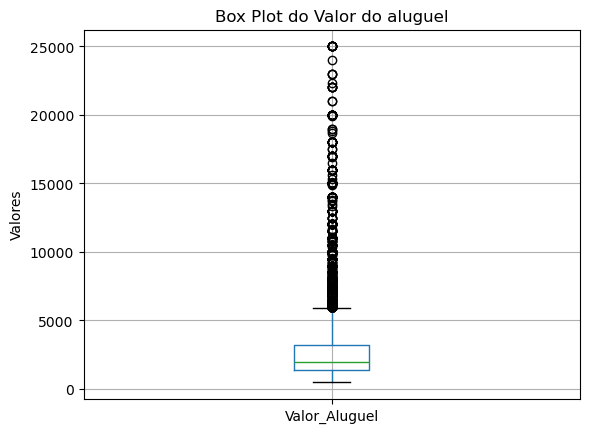

In [6]:
# Plota o gráfico Boxplot
df.boxplot(column='Valor_Aluguel')
plt.title('Box Plot do Valor do aluguel')
plt.ylabel('Valores')
plt.show()

In [7]:
Q1 = df['Valor_Aluguel'].quantile(0.25)
Q3 = df['Valor_Aluguel'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print('Primeiro quartil:',Q1,'\n')
print('Terceiro quartil:',Q3,'\n')
print('IQR:',IQR,'\n')
print('Limite inferior:',limite_inferior,' ')
print('Valor mínimo da coluna Valor_Aluguel:', df['Valor_Aluguel'].min(),'\n')
print('Limite superior:',limite_superior, ' ')
print('Valor máximo da coluna Valor_Aluguel:',df['Valor_Aluguel'].max())

Primeiro quartil: 1350.0 

Terceiro quartil: 3200.0 

IQR: 1850.0 

Limite inferior: -1425.0  
Valor mínimo da coluna Valor_Aluguel: 480 

Limite superior: 5975.0  
Valor máximo da coluna Valor_Aluguel: 25000


In [8]:
print('Quantidade de linhas cujo valor do aluguel é menor que o limite superior do Box Plot:', df[df['Valor_Aluguel'] < 5975].shape[0])

Quantidade de linhas cujo valor do aluguel é menor que o limite superior do Box Plot: 6454


In [9]:
df[df['Valor_Aluguel'] > 5975].tail(25)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
7178,20000,1920,222,4,4,3,4
7179,20000,4323,317,4,2,4,5
7180,20000,4633,314,4,4,3,5
7181,20000,2500,245,3,4,3,3
7182,21000,0,223,3,2,1,1
7183,21000,3000,208,4,4,3,3
7184,22000,2337,218,3,6,3,4
7185,22000,2450,230,3,3,2,2
7186,22000,3100,223,3,2,1,2
7187,22000,4000,262,4,5,4,4


In [10]:
print('Quantidade de outliers:', df[df['Valor_Aluguel'] > 5975].shape[0])

Quantidade de outliers: 749


Fazendo as análise, constata-se que há 749 outliers. Esse dataset é sobre aluguel de casas e as linhas com o aluguel muito alto, olhando as demais colunas, na verdade representam casas muito valoreizadas e grandes. 

Então a conclusão que chego é que esse banco de dados é muito desbalanceado e que esses outlier são importantes para uma análise completado do problema. Portanto decidi por **manter os outliers**.

### Análise coluna 'Valor_Condominio'

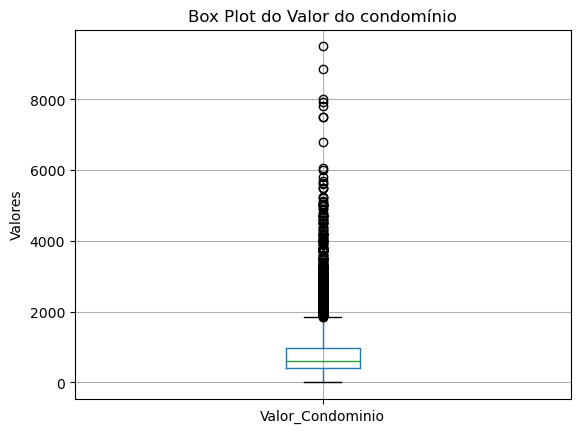

In [11]:
# Plota o gráfico Boxplot
df.boxplot(column='Valor_Condominio')
plt.title('Box Plot do Valor do condomínio')
plt.ylabel('Valores')
plt.show()

In [12]:
Q1 = df['Valor_Condominio'].quantile(0.25)
Q3 = df['Valor_Condominio'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print('Primeiro quartil:',Q1,'\n')
print('Terceiro quartil:',Q3,'\n')
print('IQR:',IQR,'\n')
print('Limite inferior:',limite_inferior,' ')
print('Valor mínimo da coluna Valor_Condominio:', df['Valor_Condominio'].min(),'\n')
print('Limite superior:',limite_superior, ' ')
print('Valor máximo da coluna Valor_Condominio:',df['Valor_Condominio'].max())

Primeiro quartil: 395.0 

Terceiro quartil: 980.0 

IQR: 585.0 

Limite inferior: -482.5  
Valor mínimo da coluna Valor_Condominio: 0 

Limite superior: 1857.5  
Valor máximo da coluna Valor_Condominio: 9500


In [13]:
print('Quantidade de linhas cujo valor do aluguel é menor que o limite superior do Box Plot:', df[df['Valor_Condominio'] < 1857.5].shape[0])
print('Quantidade de outliers:', df[df['Valor_Condominio'] > 1857.5].shape[0])

Quantidade de linhas cujo valor do aluguel é menor que o limite superior do Box Plot: 6617
Quantidade de outliers: 586


In [14]:
df[df['Valor_Condominio'] > 5500].sort_values(by=['Valor_Condominio'])

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
7192,23000,5600,364,4,5,4,5
7197,25000,5636,327,4,3,2,3
7174,20000,5705,469,4,5,4,4
7082,14000,5800,400,6,8,2,2
7201,25000,6000,600,4,5,4,8
4893,2800,6059,66,2,2,1,1
7109,15000,6800,456,4,5,4,5
5096,3000,7500,393,4,6,4,6
7198,25000,7500,627,4,5,4,6
7166,19900,7800,880,5,4,5,6


In [15]:
# Linhas em que o valor do Condomínio é maior que o valor do Aluguel
df[df['Valor_Condominio'] > df['Valor_Aluguel']].shape

(43, 7)

Essa coluna também apresenta outliers. E se enquadra na mesma situção da anterior. São casas valorizadas e consequentemente possuem valor de condomínio alto.

No entanto eu percebi algo estranho. Algumas linhas possuem o valor de aluguel menor que o valor de condomínio, o que não faz sentido. O valor do condomínio tem que ser menor que o do aluguel. Como são poucas linhas, irei removê-las.

In [16]:
# Remove as colunas cujo valor de aluguel é menor que o valor de condomínio
df = df[df['Valor_Condominio'] <= df['Valor_Aluguel']]

# Reseta os indices do dataframe
df = df.reset_index(drop=True)

### Análise coluna 'Metragem'

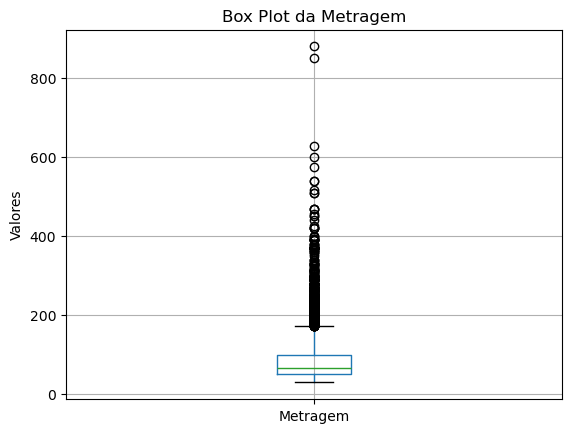

In [17]:
# Plota o gráfico Boxplot
df.boxplot(column='Metragem')
plt.title('Box Plot da Metragem')
plt.ylabel('Valores')
plt.show()

In [18]:
Q1 = df['Metragem'].quantile(0.25)
Q3 = df['Metragem'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print('Primeiro quartil:',Q1,'\n')
print('Terceiro quartil:',Q3,'\n')
print('IQR:',IQR,'\n')
print('Limite inferior:',limite_inferior,' ')
print('Valor mínimo da coluna Metragem:', df['Metragem'].min(),'\n')
print('Limite superior:',limite_superior, ' ')
print('Valor máximo da coluna Metragem:',df['Metragem'].max())

Primeiro quartil: 52.0 

Terceiro quartil: 100.0 

IQR: 48.0 

Limite inferior: -20.0  
Valor mínimo da coluna Metragem: 30 

Limite superior: 172.0  
Valor máximo da coluna Metragem: 880


In [19]:
print('Quantidade de linhas cujo valor do aluguel é menor que o limite superior do Box Plot:', df[df['Metragem'] < 172].shape[0])
print('Quantidade de outliers:', df[df['Metragem'] > 172].shape[0])

Quantidade de linhas cujo valor do aluguel é menor que o limite superior do Box Plot: 6518
Quantidade de outliers: 632


Novamento uma coluna com vários outliers. Acredito que se enquadre na mesma explicação que as anteriores, são casas valorizadas e consequentemente possuem uma metragem alta.

## Análise bivariada

### Comparação entre Metragem e o valor do condomínio

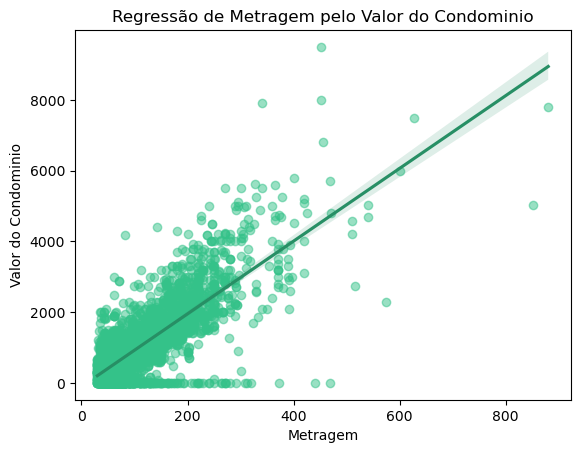

In [20]:
# Gráfico de Regressão
sns.regplot(x='Metragem', y='Valor_Condominio', data=df, color='#278f65', scatter_kws={'alpha': 0.5, 'color': '#34c289'})
plt.title('Regressão de Metragem pelo Valor do Condominio')
plt.xlabel('Metragem')
plt.ylabel('Valor do Condominio')
plt.show()

Observando o gráfico acima é possível concluir que quanto maior a área da casa maior o valor do condomínio

### Comparação entre Nº de vagas e o valor do condomínio

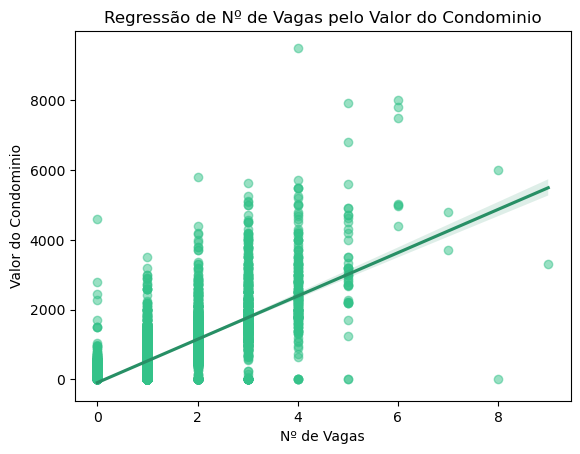

In [21]:
# Gráfico de Regressão
sns.regplot(x='N_Vagas', y='Valor_Condominio', data=df, color='#278f65', scatter_kws={'alpha': 0.5, 'color': '#34c289'})
plt.title('Regressão de Nº de Vagas pelo Valor do Condominio')
plt.xlabel('Nº de Vagas')
plt.ylabel('Valor do Condominio')
plt.show()

Observando o gráfico acima é possível concluir que quanto a quantidade de vagas maior é o valor do condomínio

### Comparação entre Nº de vagas e o Nº de suites

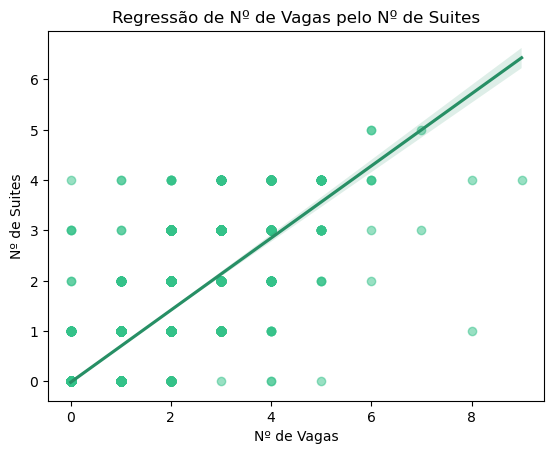

In [22]:
# Gráfico de Regressão
sns.regplot(x='N_Vagas', y='N_Suites', data=df, color='#278f65', scatter_kws={'alpha': 0.5, 'color': '#34c289'})
plt.title('Regressão de Nº de Vagas pelo Nº de Suites')
plt.xlabel('Nº de Vagas')
plt.ylabel('Nº de Suites')
plt.show()

Observando o gráfico acima é possível concluir que quanto a quantidade de vagas maior é o numero de suites.

Todas os 3 insights fazem sentido pois quanto mais valorizada uma casa, maior ela será, mais vagas e mais suites ela tende a ter.

# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




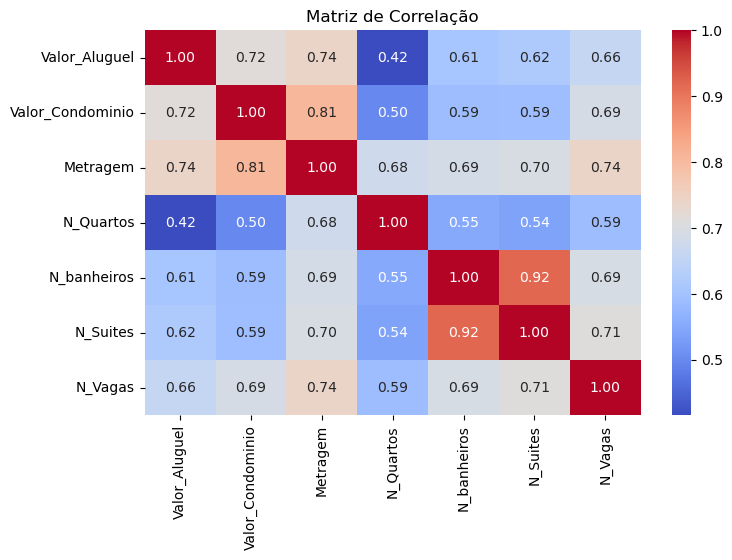

In [23]:
#Seu código aqui
correlation_matrix = df.corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

É possível ver que tanto a variável valor do condomínio quanto a variável metragem possuem uma forte correlação com o valor do aluguel. Além disso, nota-se que o valor de condomínio e a metragem também possuem forte corralação.

Mas as variáveis que possuem a maior correlação são o número de suites com o número de banheiros, o que faz muito sentido.


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [24]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

In [25]:
# Separar os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

print('Tamanho do X_train:', X_train.shape)
print('Tamanho do y_train:', y_train.shape)
print('Tamanho do X_test:', X_test.shape)
print('Tamanho do y_test:', y_test.shape)

Tamanho do X_train: (5728, 6)
Tamanho do y_train: (5728,)
Tamanho do X_test: (1432, 6)
Tamanho do y_test: (1432,)


# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [26]:
X = X_train[['Metragem']]  # Variável independente (características)
y = y_train  # Variável dependente (rótulo)
# se você deu um nome diferente para x train e y train, altere no código.

In [27]:
#Crie seu modelo aqui, usando LinearRegression e as bases de treino.
regressao_simples = LinearRegression()
regressao_simples.fit(X,y)

LinearRegression()

B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [28]:
#Seu código Aqui
print('Coeficiente angular da reta:', regressao_simples.coef_[0])
print('Constante da reta:', regressao_simples.intercept_)
print(f'\nEquação da reta: Y = {regressao_simples.coef_[0]:.2f}*X {regressao_simples.intercept_:.2f}') 

Coeficiente angular da reta: 35.50528608255988
Constante da reta: -140.33594949967755

Equação da reta: Y = 35.51*X -140.34


Nossa equação seria:   **Y = 35.51*X - 140.34**

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [29]:
#Seu código aqui
R2_treino = regressao_simples.score(X,y)
R2_treino

0.5425787753937786

O valor de R2 obtido foi de 0.54. Isso significa que 54% da variação na variável dependente é explicada pela variável independente incluída no modelo de regressão.

Esse não é um resultado muito bom. Quanto maior o valor de R2 melhor

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

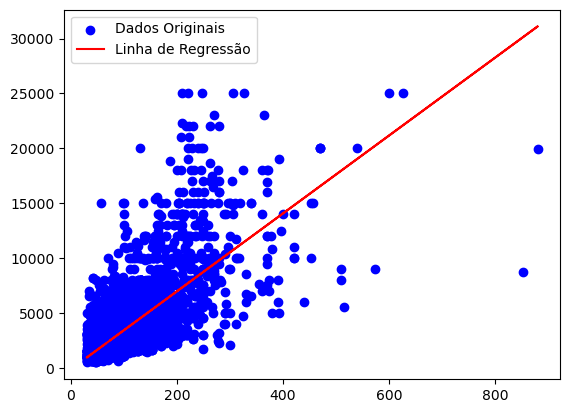

In [30]:
# Plotar os dados originais
plt.scatter(X, y, color='blue', label='Dados Originais')

# Plotar a linha de regressão
plt.plot(X, regressao_simples.predict(X), color='red', label='Linha de Regressão')
plt.legend()
plt.show()

Faz sentido o valor de R2 ter dado mediano, pois os pontos estão muito dispersos. Eles tendem um pouco a reta mas tem muita dispersão.

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [31]:
X_test = X_test[['Metragem']]  # Variável independente (características)
y_test = y_test  # Variável dependente (rótulo)

In [32]:
# Avaliando o desempenho do modelo usando métricas como o R²
r2 = regressao_simples.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)

Coeficiente de Determinação (R²) nos Dados de Teste: 0.578698103269021


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

Comparando o valor de R2 do treino e do teste vemos que deram bem próximo, isso significa que o modelo foi bem treinado e é capaz de generalizar bem para novos dados

In [33]:
print("Coeficiente de Determinação (R²) nos Dados de Treino:", R2_treino)
print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)

Coeficiente de Determinação (R²) nos Dados de Treino: 0.5425787753937786
Coeficiente de Determinação (R²) nos Dados de Teste: 0.578698103269021


# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [34]:
#seu código aqui
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

# Separar os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

print('Tamanho do X_train:', X_train.shape)
print('Tamanho do y_train:', y_train.shape)
print('Tamanho do X_test:', X_test.shape)
print('Tamanho do y_test:', y_test.shape)

Tamanho do X_train: (5728, 6)
Tamanho do y_train: (5728,)
Tamanho do X_test: (1432, 6)
Tamanho do y_test: (1432,)


B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [35]:
#seu código aqui
X = X_train  # Variável independente (características)
y = y_train  # Variável dependente (rótulo)

#Crie seu modelo aqui, usando LinearRegression e as bases de treino.
regressao_multipla = LinearRegression()
regressao_multipla.fit(X,y)

LinearRegression()

C) Traga o valor do R quadrado e avalie o valor encontrado.

In [36]:
#seu código aqui
R2_multi = regressao_multipla.score(X,y)
R2_multi

0.6233168167487522

O valor obtido foi de 0,62. Esse valor é consideravelemente maior que o valor obtido anteriormente, usando apenas a coluna 'Metragem'. Isso significa que o modelo está melhor treinado.

D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [37]:
#seu código aqui
X_test = X_test  # Variável independente (características)
y_test = y_test  # Variável dependente (rótulo)

# Avaliando o desempenho do modelo usando métricas como o R²
r2_multi = regressao_multipla.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2_multi)

Coeficiente de Determinação (R²) nos Dados de Teste: 0.6539977816750785


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

In [38]:
print("Coeficiente de Determinação (R²) na Regressão Linear:", r2)
print("Coeficiente de Determinação (R²) na Regressão Múltipla:", r2_multi)

Coeficiente de Determinação (R²) na Regressão Linear: 0.578698103269021
Coeficiente de Determinação (R²) na Regressão Múltipla: 0.6539977816750785


Como é possível constatar, a regressão múltipla resulta em um R2 maior. Isso acontece porque ela utiliza mais variáveis para treinar o modelo. O modelo fica mais complexo, mais completo e por isso gera um resultado melhor.